# Task 2: Customer Segmentation Analysis

## Objective
Segment an e-commerce company's customer base into distinct groups
based on purchasing behaviour using RFM analysis and K-Means clustering.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### 1. Import Libraries & Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("Online Retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### 2. Inspect the Dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


### 3. Clean the Data

In [11]:
#Remove missing Customer IDs
df = df.dropna(subset=["CustomerID"])

In [12]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### 4. Remove Invalid Transactions

In [13]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8905)

In [14]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

### 5. Remove Invalid Quantities and Prices

In [15]:
#Quantity
df = df[df["Quantity"] > 0]

#Unit price
df = df[df["UnitPrice"] > 0]


### 6. Convert Date Column

In [17]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    dayfirst=True
)
df["InvoiceDate"].min()
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

### 7. Create Revenue Column

In [18]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [19]:
df[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### 8. Descriptive Statistics

In [21]:
customer_summary = df.groupby("CustomerID").agg(
    Total_Spend=("TotalPrice", "sum"),
    Total_Orders=("InvoiceNo", "nunique"),
    Total_Items=("Quantity", "sum")
).reset_index()

customer_summary.head()

,CustomerID,Total_Spend,Total_Orders,Total_Items
0,12346.0,77183.60,1,74215
1,12347.0,4310.00,7,2458
2,12348.0,1797.24,4,2341
3,12349.0,1757.55,1,631
4,12350.0,334.40,1,197


#### Average Purchase Value

In [22]:
average_purchase_value = (
    df["TotalPrice"].sum() / df["InvoiceNo"].nunique()
)

average_purchase_value

np.float64(480.8659563997409)

In [66]:
customer_summary["Average_Order_Value"] = (
    customer_summary["Total_Spend"] /
    customer_summary["Total_Orders"]
)
customer_summary

,CustomerID,Total_Spend,Total_Orders,Total_Items,Average_Order_Value,Customer_Lifetime_Value
0,12346.0,77183.60,1,74215,77183.600000,77183.60
1,12347.0,4310.00,7,2458,615.714286,4310.00
2,12348.0,1797.24,4,2341,449.310000,1797.24
3,12349.0,1757.55,1,631,1757.550000,1757.55
4,12350.0,334.40,1,197,334.400000,334.40
...,...,...,...,...,...,...
4333,18280.0,180.60,1,45,180.600000,180.60
4334,18281.0,80.82,1,54,80.820000,80.82
4335,18282.0,178.05,2,103,89.025000,178.05
4336,18283.0,2094.88,16,1397,130.930000,2094.88


#### Purchase Frequency

In [24]:
customer_summary["Total_Orders"].describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: Total_Orders, dtype: float64

#### Customer Lifetime Value

In [26]:
customer_summary["Customer_Lifetime_Value"] = (
    customer_summary["Total_Spend"]
)

In [27]:
customer_summary["Customer_Lifetime_Value"].describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: Customer_Lifetime_Value, dtype: float64

### 9. RFM Analysis
R = Recency
F = Frequency
M = Monetary

#### Determine Analysis Date

In [28]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

analysis_date

Timestamp('2011-12-10 12:50:00')

#### Calculate Recency

In [29]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

In [30]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [31]:
rfm = rfm.reset_index()
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


### 10. Inspect RFM Statistics

In [32]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [33]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

In [34]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   float64
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB


### 11. Visualize RFM Distributions

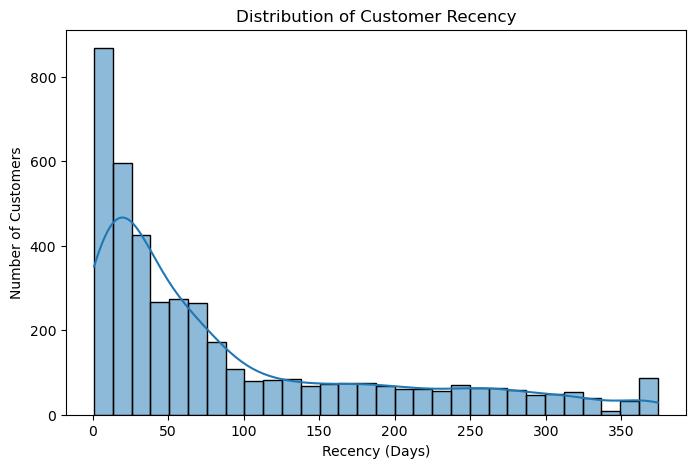

In [35]:
#Recency
plt.figure(figsize=(8, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

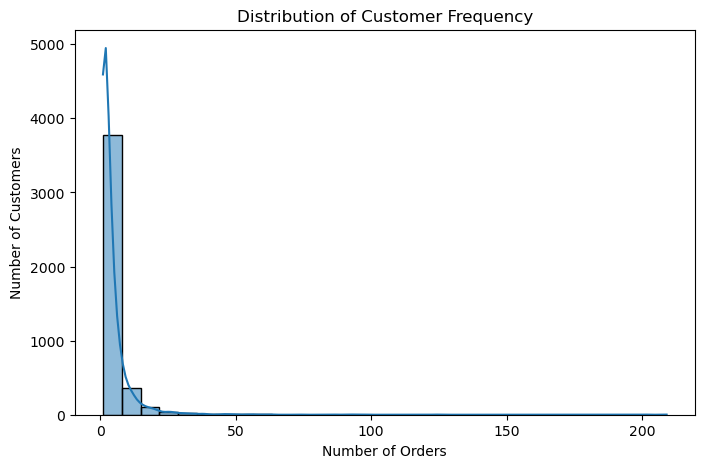

In [37]:
#Frequency
plt.figure(figsize=(8, 5))

sns.histplot(rfm["Frequency"], bins=30, kde=True)

plt.title("Distribution of Customer Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

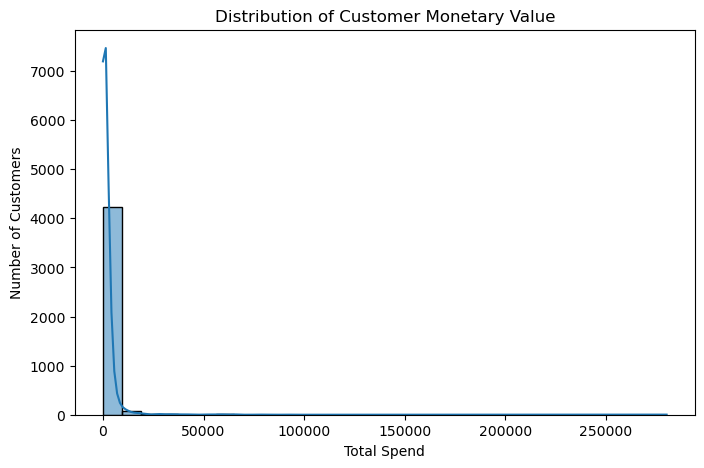

In [38]:
#Monetary
plt.figure(figsize=(8, 5))

sns.histplot(rfm["Monetary"], bins=30, kde=True)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")

plt.show()

### 12. Feature Selection

In [39]:
features = rfm[
    ["Recency", "Frequency", "Monetary"]
]

### 13. Handle Skewness

In [41]:
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.324953
dtype: float64

In [43]:
rfm_log = np.log1p(
    rfm[["Recency", "Frequency", "Monetary"]]
)
rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


### 14. Standardize the Data

In [44]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [45]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)
rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.706225
1,-2.038734,1.074425,1.411843
2,0.373104,0.386304,0.716489
3,-0.623086,-0.955214,0.698739
4,1.424558,-0.955214,-0.618962


#### Why Standardization Is Important
Recency     → 5–300
Frequency   → 1–200
Monetary    → 100–100000

Monetary has much larger numbers.

K-Means uses distance calculations, so Monetary could dominate the clustering.

StandardScaler transforms the variables to a comparable scale.

Conceptually:
Original data
     ↓
Log transformation
     ↓
StandardScaler
     ↓
Data ready for K-Means

### 15. Find Optimal Number of Clusters

In [46]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

#### Plot Elbow Method

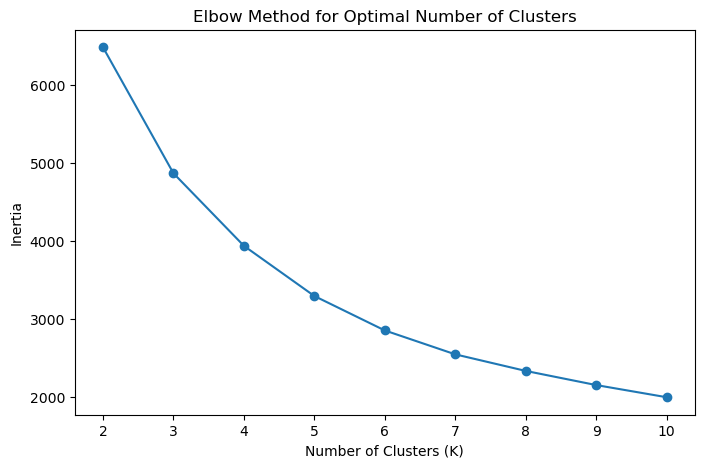

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(range(2, 11))

plt.show()

### 16. Apply K-Means

In [48]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,2
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,3


### 17. Profile Each Cluster

In [49]:
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(
    columns={"CustomerID": "Customer_Count"}
)

cluster_profile

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,18.124253,2.148148,551.819534,837
1,12.131285,13.713687,8074.266872,716
2,71.084399,4.083546,1802.829005,1173
3,182.496898,1.318238,343.450032,1612


In [50]:
cluster_profile.sort_values("Monetary", ascending=False)

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
1,12.131285,13.713687,8074.266872,716
2,71.084399,4.083546,1802.829005,1173
0,18.124253,2.148148,551.819534,837
3,182.496898,1.318238,343.450032,1612


### 18. Create Customer Segment Names

In [51]:
segment_names = {
    0: "Loyal Customers",
    1: "At-Risk Customers",
    2: "Potential Customers",
    3: "High-Value Customers"
}

In [52]:
rfm["Segment"] = rfm["Cluster"].map(segment_names)

In [53]:
cluster_profile

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,18.124253,2.148148,551.819534,837
1,12.131285,13.713687,8074.266872,716
2,71.084399,4.083546,1802.829005,1173
3,182.496898,1.318238,343.450032,1612


### 19. Required Visualization

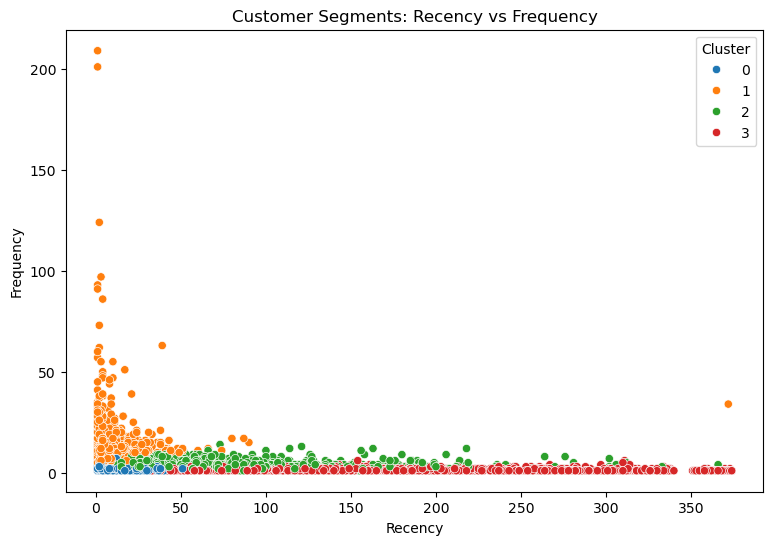

In [54]:
#Recency vs Frequency 
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency")
plt.ylabel("Frequency")

plt.show()

### Required Visualization

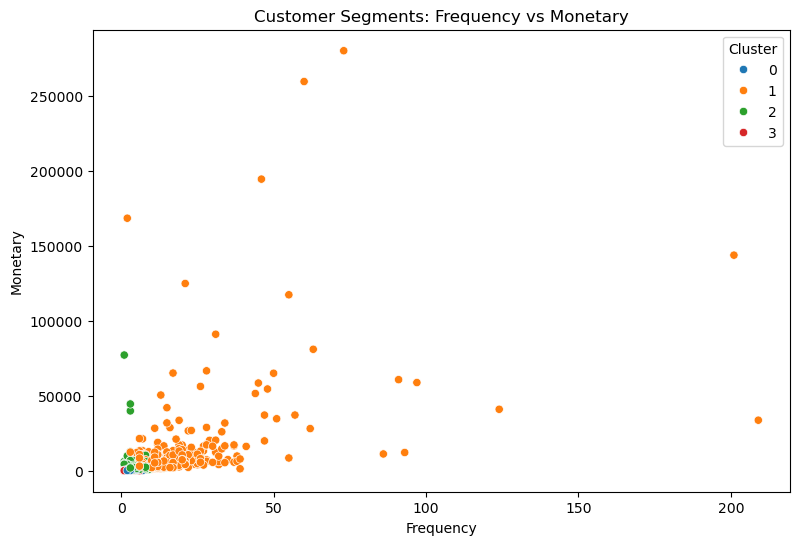

In [55]:
#Frequency vs Monetary
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

### Optional Third Scatter Plot

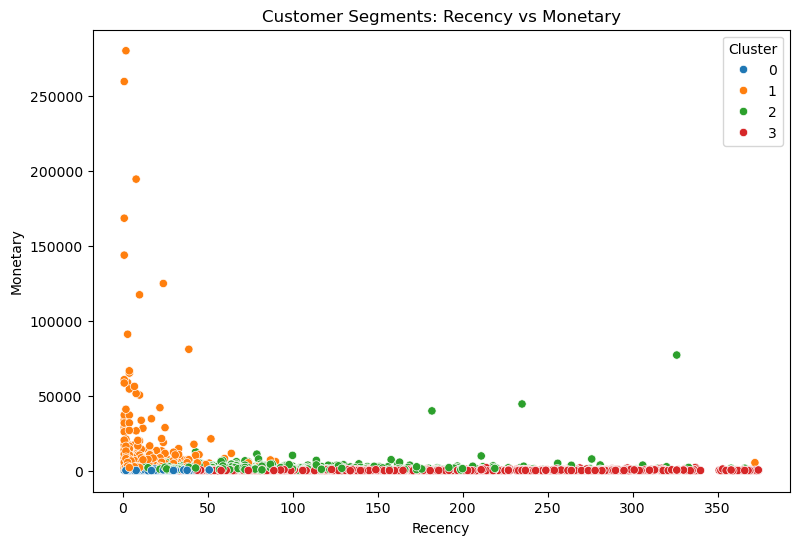

In [56]:
#Recency vs Monetary
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()

### 20. Required Bar Chart

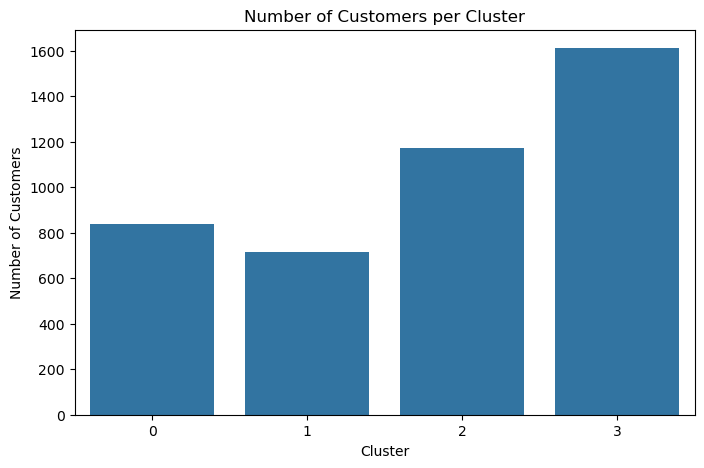

In [57]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

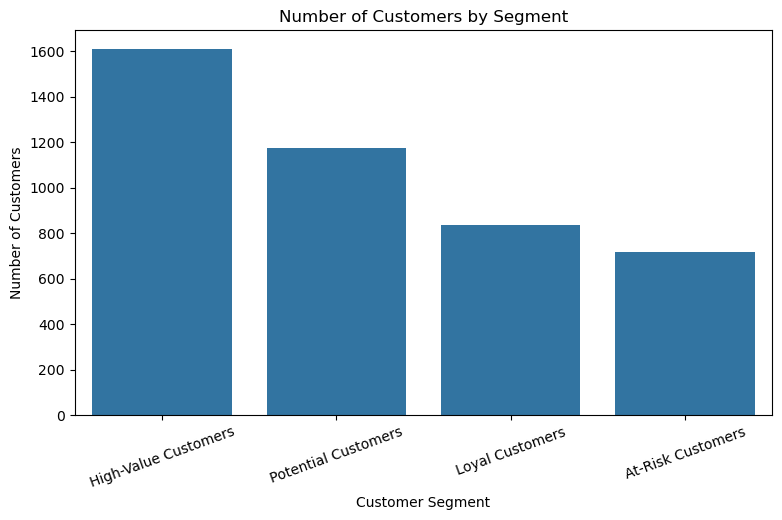

In [58]:
#Use Segment Names
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### 21. Create a Cluster Profile Heatmap

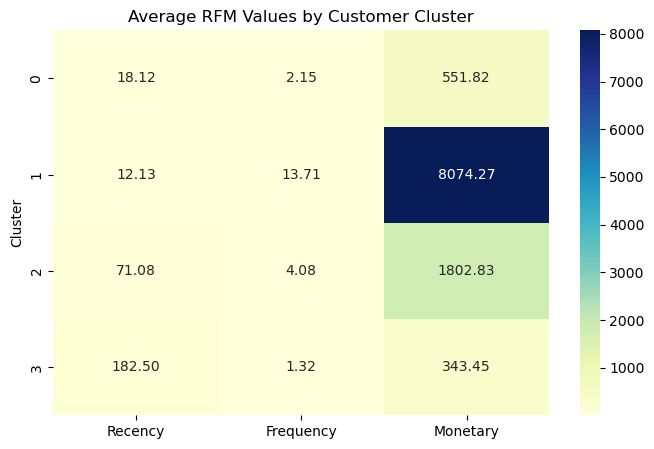

In [59]:
profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

plt.figure(figsize=(8, 5))

sns.heatmap(
    profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average RFM Values by Customer Cluster")

plt.show()

### 22. Marketing Insights

| Customer Segment         | Behaviour                            | Recommended Action                               |
| ------------------------ | ------------------------------------ | ------------------------------------------------ |
| **High-Value Customers** | Recent, frequent and high spending   | VIP rewards, exclusive offers, loyalty program   |
| **Loyal Customers**      | Frequent purchases and good spending | Cross-selling, upselling and loyalty rewards     |
| **Potential Customers**  | Moderate activity and spending       | Personalized offers and product recommendations  |
| **At-Risk Customers**    | Long time since purchase             | Win-back campaigns, discounts and reminders      |
| **Low-Value Customers**  | Low frequency and low spending       | Low-cost email campaigns and targeted promotions |

Cluster 2 has the lowest average Recency, highest Frequency,
and highest Monetary value. Therefore, it is classified as
the High-Value Customer segment.


### 23. Final Summary Table

In [60]:
final_profile = rfm.groupby("Segment").agg(
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Monetary=("Monetary", "mean"),
    Customer_Count=("CustomerID", "count")
).round(2)

final_profile

,Average_Recency,Average_Frequency,Average_Monetary,Customer_Count
Segment,,,,
At-Risk Customers,12.13,13.71,8074.27,716
High-Value Customers,182.50,1.32,343.45,1612
Loyal Customers,18.12,2.15,551.82,837
Potential Customers,71.08,4.08,1802.83,1173


### 24. Percentage of Customers

In [61]:
final_profile["Customer_Percentage"] = (
    final_profile["Customer_Count"] /
    final_profile["Customer_Count"].sum()
) * 100

In [63]:
final_profile["Customer_Percentage"] = (
    final_profile["Customer_Percentage"].round(2)
)

In [64]:
final_profile

,Average_Recency,Average_Frequency,Average_Monetary,Customer_Count,Customer_Percentage
Segment,,,,,
At-Risk Customers,12.13,13.71,8074.27,716,16.51
High-Value Customers,182.50,1.32,343.45,1612,37.16
Loyal Customers,18.12,2.15,551.82,837,19.29
Potential Customers,71.08,4.08,1802.83,1173,27.04


### 25. Business Insights

#### 1. High-Value Customers
These customers show high purchase frequency and monetary value
with recent purchasing activity. They should be retained through
VIP benefits, loyalty rewards and exclusive offers.

#### 2. Loyal Customers
These customers purchase regularly and contribute significant
revenue. Cross-selling, upselling and loyalty programs can
increase their lifetime value.

#### 3. Potential Customers
These customers demonstrate moderate engagement and spending.
Personalized recommendations and targeted promotions can encourage
more frequent purchases.

#### 4. At-Risk Customers
These customers have relatively high recency values, indicating
that they have not purchased recently. Win-back campaigns,
personalized discounts and reminder emails can help reactivate them.

### 27. Final Conclusion

RFM analysis was used to understand customer purchasing behaviour
based on Recency, Frequency and Monetary value. The RFM features
were transformed and standardized before applying K-Means clustering.

The Elbow Method was used to determine an appropriate number of
customer segments. The resulting clusters revealed distinct
customer behaviour patterns, ranging from high-value loyal customers
to less-engaged and potentially at-risk customers.

These segments can help the business develop targeted marketing
strategies, improve customer retention and focus resources on
high-value and high-potential customers.